In [2]:
from langchain_core.messages import HumanMessage
from langchain_chroma import Chroma
import chromadb

from src.models import load_models, load_embeddings
from src.graph import build_graph
from src.utils.get_persona import generate_king_config
from src.utils.gen_scene import generate_initial_scene
from src.config import KING_CONFIG_FALLBACK

def start_chat(app_graph, llm_generator):
    print('\n' + '='*60)
    print("📜 조선 왕조 실록 챗봇에 오신 것을 환영합니다.")
    print('='*60)
    
    king_name = input('대화할 조선의 왕을 선택해주세요. (예: 태조, 세종, 단종, 세조, 연산군 등): ')
    if king_name == '태조':
        king_name = '태조 이성계'
        
    king_data = generate_king_config(king_name, llm=llm_generator)
    
    if not king_data:
            king_data = KING_CONFIG_FALLBACK.get(king_name)

            if king_data:
                print(f"\n⚠️ [시스템] 페르소나 동적 생성에 실패하여 백업된 '{king_name}' 설정으로 대화를 시작합니다.")
            else:
                print(f"\n⚠️ [시스템] '{king_name}' 전하의 데이터를 찾을 수 없습니다. (생성 실패 및 백업 데이터 없음)")
                print('프로그램을 종료합니다. 다른 왕의 이름으로 다시 시도해 주세요.')
                return 

    persona_summary = king_data['persona_summary']
    speech_style = king_data['speech_style']
    core_values = king_data['core_values']
    sensitive_topics = king_data['sensitive_topics']
    anger_bias = king_data.get('anger_bias', 0)

    print('''
[신분 선택 가이드]
- 백성: 왕과 가장 큰 거리가 있는 존재. 극도의 긴장과 두려움.
- 유생: 예를 갖추어 아뢰지만, 학문과 명분을 앞세움.
- 신하: 군신 관계가 분명하여 늘 신중함.
- 장수: 실무적으로는 가깝지만 엄격한 위계가 있음.
- 상인: 신분 차이 앞에서는 조심스럽고 위축됨.
- 의원: 왕의 몸을 다루는 만큼 극도로 신중함.
- 내관/궁인: 물리적 거리는 가깝지만 행동 하나하나 조심.
- 중국 황제: 대등한 위치, 외교적 체면과 긴장.
- 학생: 역사 공부용 챗봇모드. (배경 묘사 생략)
''')
    user_role = input('본인의 신분을 선택해주세요: ')

    initial_scenario = generate_initial_scene(king_name, persona_summary, user_role, llm_generator)

    current_state = {
        'messages': [],
        'king_name': king_name,
        'persona_summary': persona_summary,
        'speech_style': speech_style,
        'core_values': core_values,
        'sensitive_topics': sensitive_topics,
        'user_role': user_role,
        'scenario': initial_scenario,
        'anger_level': 0,
        'anger_bias': anger_bias,
    }
    
    print('\n' + '='*60)
    print(f"👑 {current_state['king_name']} 전하와의 대화가 시작되었습니다. (종료: 'q', '종료')")
    print('-' * 60)
    if current_state['scenario']:
        print(f"📜 [상황]: {current_state['scenario']}")
    print('='*60)

    while True:
        user_input = input(f'\n{user_role} (나): ')
        
        if user_input.strip() in ['종료', 'exit', 'quit', 'q']:
            print('\n대화가 종료되었습니다.')
            break
            
        current_state['messages'].append(HumanMessage(content=user_input))
        current_state = app_graph.invoke(current_state)
        
        king_response = current_state['messages'][-1].content
        new_scenario = current_state.get('scenario', '')
        anger = current_state.get('anger_level', 0)

        print('-' * 60)
        if new_scenario:
            print(f"📜 [상황]: {new_scenario}")
            print('-' * 60)
            
        print(f"[전하의 분노: {anger}/100]")
        print(f"{current_state['king_name']}: {king_response}")
        print('-' * 60)


if __name__ == "__main__":
    print("로컬 모델 및 벡터 DB를 불러오는 중입니다. 잠시만 기다려주세요...")
    llms = load_models()
    llm_analyzer = llms["analyzer"]
    llm_generator = llms["generator"]
    
    embeddings = load_embeddings()
    persistent_client = chromadb.PersistentClient(path="./database/reference_db")
    vectorstore = Chroma(
        client=persistent_client, 
        embedding_function=embeddings, 
        collection_name='reference'
    )

    app_graph = build_graph(llm_analyzer, llm_generator, vectorstore)

    app_graph
    # start_chat(app_graph, llm_generator)

로컬 모델 및 벡터 DB를 불러오는 중입니다. 잠시만 기다려주세요...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

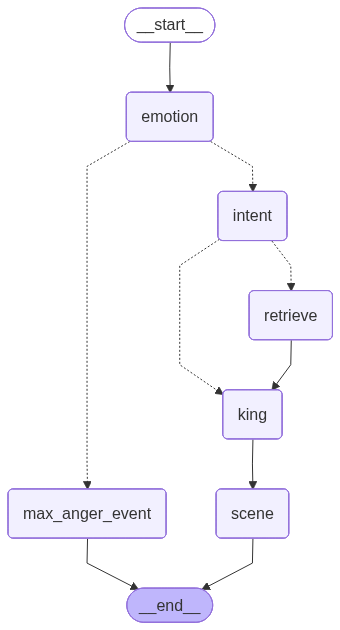

In [3]:
app_graph

In [4]:
start_chat(app_graph, llm_generator)


📜 조선 왕조 실록 챗봇에 오신 것을 환영합니다.


[transformers] The remote code model you are currently using seems to expect `cache_position`. This arg has been removed from the Transformers library, and will stop being created in `generate` even for remote code models in a future release. Please open a PR on the remote code hub repo to remove any usage of `cache_position`.


🔍 [태조 이성계] 전하의 실록 데이터를 바탕으로 페르소나를 구축 중입니다...


c:\Users\Playdata\miniconda3\envs\da_env\Lib\site-packages\bitsandbytes\backends\cpu\ops.py:80: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\Playdata\miniconda3\envs\da_env\Lib\site-packages\bitsandbytes\backends\cpu\ops.py:132: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


✅ 페르소나 구축 완료!

[신분 선택 가이드]
- 백성: 왕과 가장 큰 거리가 있는 존재. 극도의 긴장과 두려움.
- 유생: 예를 갖추어 아뢰지만, 학문과 명분을 앞세움.
- 신하: 군신 관계가 분명하여 늘 신중함.
- 장수: 실무적으로는 가깝지만 엄격한 위계가 있음.
- 상인: 신분 차이 앞에서는 조심스럽고 위축됨.
- 의원: 왕의 몸을 다루는 만큼 극도로 신중함.
- 내관/궁인: 물리적 거리는 가깝지만 행동 하나하나 조심.
- 중국 황제: 대등한 위치, 외교적 체면과 긴장.
- 학생: 역사 공부용 챗봇모드. (배경 묘사 생략)

🎬 [배경 생성] 태조 이성계 전하를 대면하기 전, 상황을 준비 중입니다...

👑 태조 이성계 전하와의 대화가 시작되었습니다. (종료: 'q', '종료')
------------------------------------------------------------
📜 [상황]: 웅장한 목조로 이루어진 궁궐의 중심에 위치한 왕대는, 햇살이 깊게 스며들어 차가운 석판 위에 황금빛으로 빛나는 그림자를 그려냈다. 왕의 거처인 궁궐 안은 엄격한 예법과 질서가 공기 속에 울려 퍼져 있었고, 그 안에서는 태조 이성계의 위엄과 함께 백성들의 존재를 엿볼 수 있었다. 그러나 이곳에서는 아직 아무도 왕을 직접 대면하지 못했다. 그의 뒤에는 항상 신하들이 있었고, 그들은 왕의 명령을 전하거나 보고를 올리는 역할을 맡아왔다. 방문자가 이곳에 들어서자, 공기는 갑자기 경직되었다. 신분 차이의 무게가 무거워지며, 모든 이들의 시선이 방문자에게로 집중되었다. 왕의 존재 앞에 선 방문자는 깊은 숨을 들이마시며, 가슴 속 깊은 곳에서는 마치 칼날이 춤추는 듯한 긴장감이 솟아올랐다.

대화가 종료되었습니다.
